## Hometask 

1) Classify the signs (fingers)  dataset 

2) Try to change the number of hidden layer 

3) Change the activation to tanh or sigmoid and see what happens

4) Change the dropout ratio and check the performance

In [4]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import pandas as pd
import seaborn as sns

In [5]:
def load_dataset():
    fn = 'supplementary_data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn = 'supplementary_data/test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes

train_data, train_labels, test_data, test_labels, classes = load_dataset()

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


In [6]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

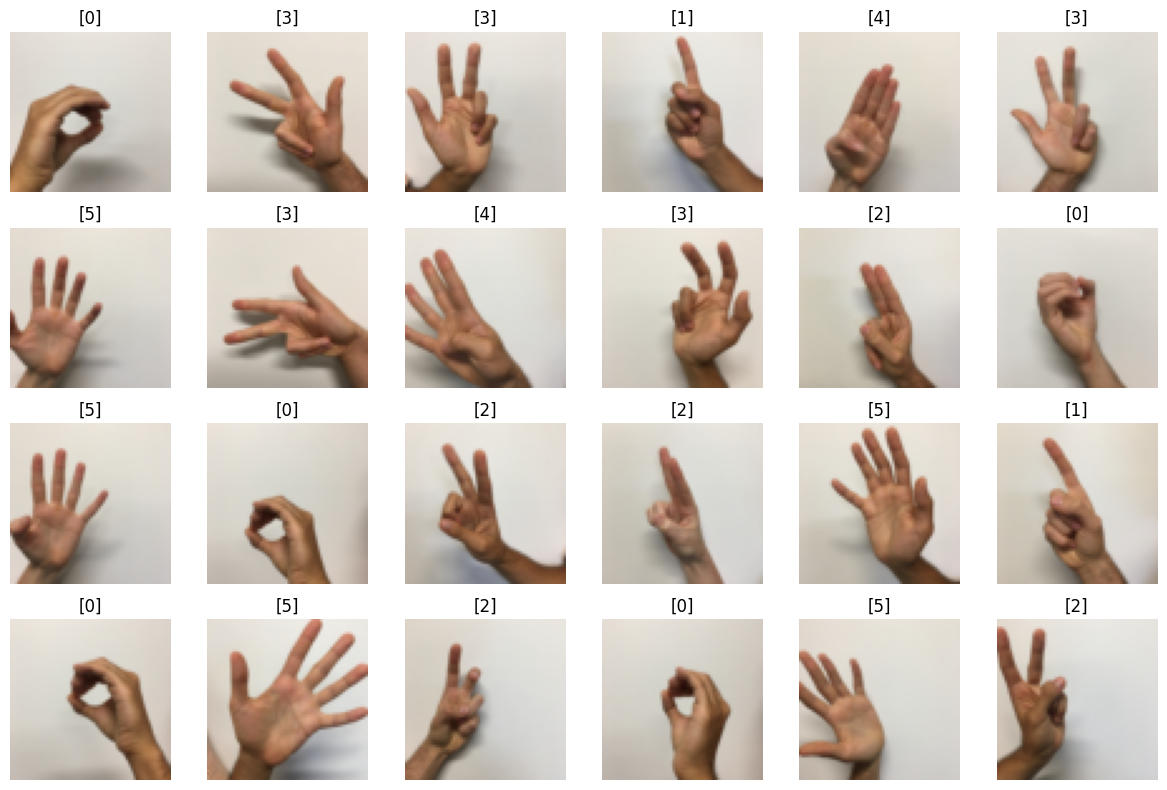

In [7]:
plt.figure(figsize= (12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y= train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

In [8]:
X_train = train_data / 255.0
X_test = test_data / 255.0

In [9]:
y_train = to_categorical(train_labels.flatten())
y_test = to_categorical(test_labels.flatten())
input_shape = X_train.shape[1:]

In [10]:
def build_model(input_shape, activation='relu', dropout1=0.25, dropout2=0.25, dropout3=0.5, dense_units=128):
    model = Sequential([
        Conv2D(32, (3, 3), activation=activation, input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Dropout(dropout1),

        Conv2D(64, (3, 3), activation=activation),
        MaxPooling2D((2, 2)),
        Dropout(dropout2),

        Flatten(),
        Dense(dense_units, activation=activation),
        Dropout(dropout3),
        Dense(6, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [11]:
def train_and_plot(model, name='Model'):
    history = model.fit(X_train, y_train, epochs=20, batch_size=32, 
                        validation_data=(X_test, y_test), verbose=0)
    
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f'{name} - Test Accuracy: {test_accuracy:.4f}')

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f'{name} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title(f'{name} - Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return test_accuracy


Dense - 128 - Test Accuracy: 0.9250


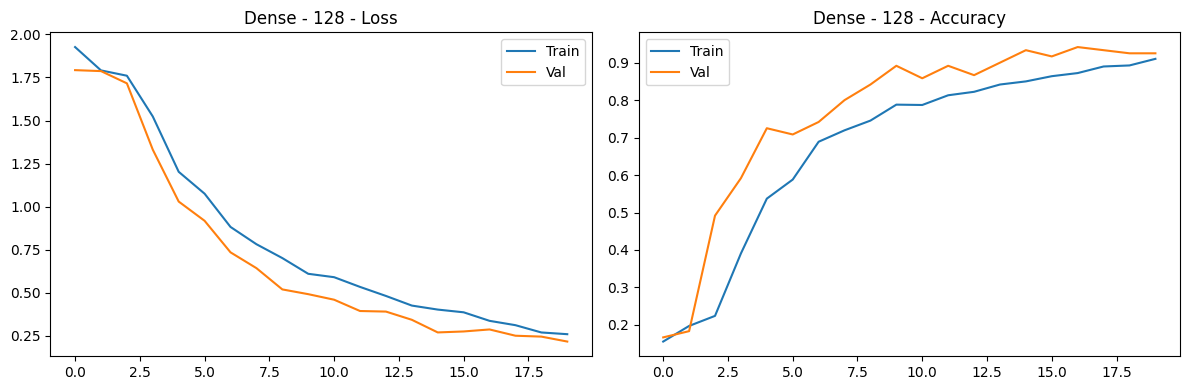

0.925000011920929

In [20]:
hidden_layer_model = build_model(input_shape,dense_units=128)
train_and_plot(hidden_layer_model, name='Dense - 128')


## Experiments:

In [16]:
results = []
def run_experiment(input_shape, activation='relu', dense_units=128, dropout=0.5):
    model = build_model(input_shape=input_shape, activation=activation, 
                        dense_units=dense_units,
                        dropout1=dropout, dropout2=dropout, dropout3=dropout)
    
    history = model.fit(X_train, y_train, epochs=20, batch_size=32,
                        validation_data=(X_test, y_test), verbose=0)

    val_accuracy = history.history['val_accuracy'][-1]
    results.append({
        'activation': activation,
        'hidden_layers': dense_units,
        'dropout': dropout,
        'val_accuracy': val_accuracy
    })

    print(f" Activation func={activation}, number_of_units={dense_units}, dropout={dropout} --- val_accuracy={val_accuracy:.4f}")

In [17]:
for activation in ['relu', 'tanh', 'sigmoid']:
    for units in [64, 128, 256]:
        for dropout in [0.2, 0.5, 0.7]:
            run_experiment(input_shape=X_train.shape[1:], 
                           activation=activation, 
                           dense_units=units, 
                           dropout=dropout)

 Activation func=relu, number_of_units=64, dropout=0.2 --- val_accuracy=0.9250
 Activation func=relu, number_of_units=64, dropout=0.5 --- val_accuracy=0.7750
 Activation func=relu, number_of_units=64, dropout=0.7 --- val_accuracy=0.1667
 Activation func=relu, number_of_units=128, dropout=0.2 --- val_accuracy=0.9417
 Activation func=relu, number_of_units=128, dropout=0.5 --- val_accuracy=0.8000
 Activation func=relu, number_of_units=128, dropout=0.7 --- val_accuracy=0.7167
 Activation func=relu, number_of_units=256, dropout=0.2 --- val_accuracy=0.9417
 Activation func=relu, number_of_units=256, dropout=0.5 --- val_accuracy=0.9083
 Activation func=relu, number_of_units=256, dropout=0.7 --- val_accuracy=0.8333
 Activation func=tanh, number_of_units=64, dropout=0.2 --- val_accuracy=0.9250
 Activation func=tanh, number_of_units=64, dropout=0.5 --- val_accuracy=0.8833
 Activation func=tanh, number_of_units=64, dropout=0.7 --- val_accuracy=0.8167
 Activation func=tanh, number_of_units=128, dr

In [18]:
results_df = pd.DataFrame(results)

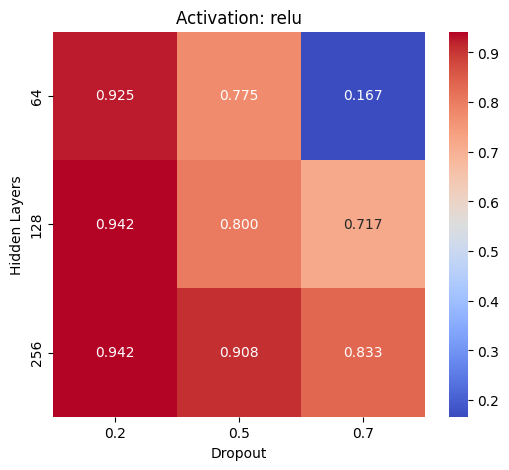

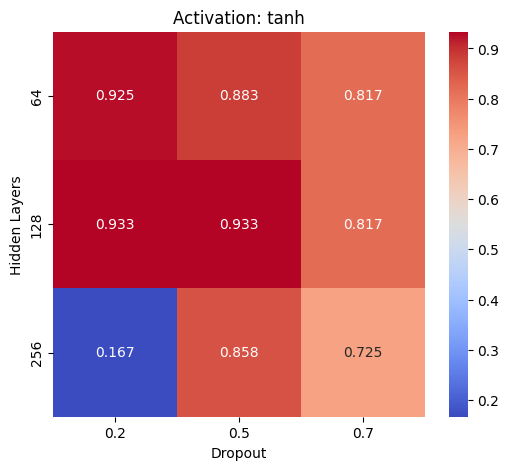

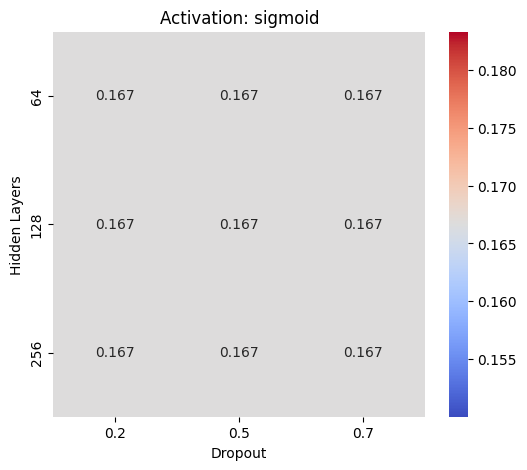

In [19]:
for act in results_df['activation'].unique():
    subset = results_df[results_df['activation'] == act]
    pivot = subset.pivot_table(index='hidden_layers', columns='dropout', values='val_accuracy')
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm")
    plt.title(f"Activation: {act}")
    plt.xlabel("Dropout")
    plt.ylabel("Hidden Layers")
    plt.show()

## Висновки:

## 1. Функція активації

- **ReLU** показала найкращі результати серед усіх активаційних функції, 128 і 256 нейронів з Dropout 0.2 показали точність валідації  0.9417, що є найвищим показником у всьому експерименті.
  
- **Tanh** загалом показав трохи меньші результати але також показала хороші результати на середній кількості нейронів та помірному Dropout. Наприклад, 128 нейронів і Dropout 0.2–0.5 дали точність 0.9333.

- **Sigmoid** значно поступався іншим функціям, в усіх комбінаціях точність залишалась на рівні 0.1667, що скоріш всього вказує на провал навчання і цим самим демонструвало випадкове вгадування.

## 2. Dropout

- Низький Dropout в 0.2 часто давав найкращі результати, набільщ в ReLU з 128 або 256 нейронами з точністю 0.9417.

- Dropout 0.5 мав найбільший результат в ReLU з 256 нейронами з точністю - 0.9083, але зазвичай знижував точність.

- Високий Dropout в 0.7 мав негативний ефект у всіх випадках, особливо при ReLU + 64, де точність впала аж до 0.1667.
  
## 4. Кількості шарів

- **64 нейрони**:
  - ReLU і Tanh дають непогані результати при низькому Dropout до 0.9250.
  - Високий Dropout (0.7) значно погіршує точність, особливо в комбінації з ReLU - 0.1667.
  - Sigmoid не працює взагалі.

- **128 нейронів**:
  - ReLU і Tanh дають стабільно високі результати до 0.9417.
  - Dropout 0.2–0.5 — є оптимальним діапазоном.
  - Sigmoid — провал у всіх випадках.

- **256 нейронів**:
  - ReLU — найкраща комбінація 0.9417 при Dropout 0.2.
  - Tanh працює гірше при малому Dropout, але краще при 0.5 - 0.8583.
  - Sigmoid знову ж — неефективний.

## 3. Підсумок

- Найкращі результати досягаються при використанні активації ReLU з 128–256 нейронами та Dropout 0.2, тоді як Sigmoid зовсім не працює в цій задачі незалежно від параметрів.
